In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Seconds to cut

In [2]:
time_cut = 15

## Specify path

In [19]:
PATH_TO_EXERCISE_FOLDER = "DMP_9D_ACCEL_Logs/shoulder_press/"
CLEANED_EXERCISE_PATH = "DMP_9D_ACCEL_Logs/cleaned/shoulder_press/"
NON_EXERCISE_PATH = "DMP_9D_ACCEL_Logs/cleaned/non_exersice/"

PLOT_GRAPH = True
GRPAH_PATH = "DMP_9D_ACCEL_Logs/graph/"

In [20]:
if not os.path.exists(CLEANED_EXERCISE_PATH):
    os.makedirs(CLEANED_EXERCISE_PATH)

if not os.path.exists(NON_EXERCISE_PATH):
    os.makedirs(NON_EXERCISE_PATH)

if not os.path.exists(GRPAH_PATH) and PLOT_GRAPH:
    os.makedirs(GRPAH_PATH)

In [21]:
excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(excersise_files)

['DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press1.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press10.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press11.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press12.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press13.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press14.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press15.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press16.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press17.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press18.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press19.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press2.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press20.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press21.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press22.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press23.csv', 'DMP_9D_ACCEL_Logs/shoulder_press/shoulder_press24.csv', 'DMP_9D_ACCEL_Logs/shoulder_pres

# Process one csv dataframe

In [6]:
df = pd.read_csv(excersise_files[0])

In [7]:
df = df.rename(columns={
    'ax': 'q0',
    'ay': 'q1',
    'az': 'q2',
    'q0': 'q3'
})

# delete unnecessary indexes
df = df.iloc[:, :(5)]

### Convert millisec to sec

In [8]:
tSec = (df['timeMs'] - df['timeMs'].iloc[0])/1000

### Determine index for cutting

In [9]:
cut_index = (tSec > time_cut).idxmax()

### Data cleaning by index

In [10]:
# split df
df_noise = df.iloc[:cut_index]
df_clean = df.iloc[cut_index:]

## Plot graphs

### Noise 

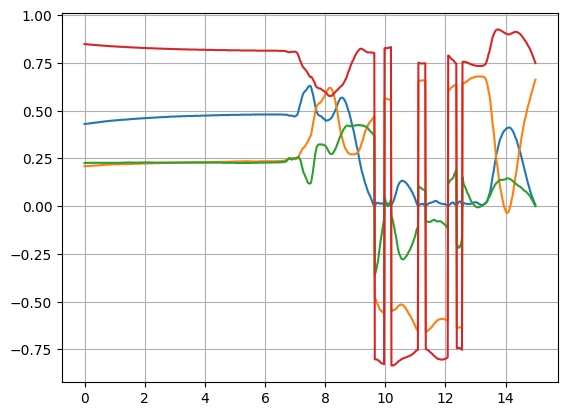

In [11]:
plt.plot(tSec[:cut_index], df_noise['q0'], label='q0')
plt.plot(tSec[:cut_index], df_noise['q1'], label='q1')
plt.plot(tSec[:cut_index], df_noise['q2'], label='q2')
plt.plot(tSec[:cut_index], df_noise['q3'], label='q3')
plt.grid()

### Data

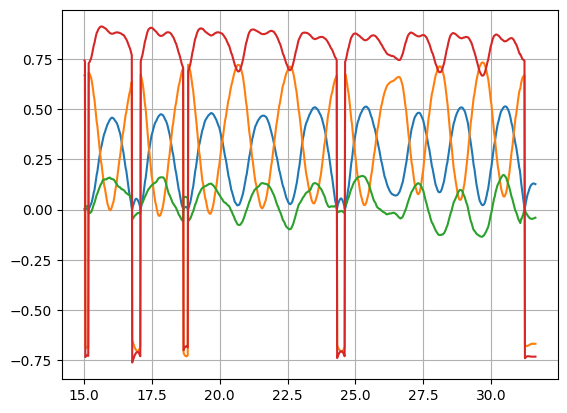

In [12]:
plt.plot(tSec[cut_index:], df_clean['q0'], label='q0')
plt.plot(tSec[cut_index:], df_clean['q1'], label='q1')
plt.plot(tSec[cut_index:], df_clean['q2'], label='q2')
plt.plot(tSec[cut_index:], df_clean['q3'], label='q3')
plt.grid()

## Save dataframes

In [77]:
df_noise.to_csv('DMP_9D_ACCEL_Logs/cleaned/non_exersice/front_raise_non_exersice1.csv', index=False)
df_clean.to_csv('DMP_9D_ACCEL_Logs/cleaned/front_raise/front_raise1.csv', index=False)


# Process all dataframes in folder

In [ ]:
for file_path in excersise_files:
    csv_filename = os.path.basename(file_path)

    df = pd.read_csv(file_path)

    df = df.rename(columns={
    'ax': 'q0',
    'ay': 'q1',
    'az': 'q2',
    'q0': 'q3'
    })   
    df = df.iloc[:, :(5)]
    tSec = (df['timeMs'] - df['timeMs'].iloc[0])/1000

    if PLOT_GRAPH:
        plt.figure(figsize=(10, 6))
        plt.plot(tSec, df['q0'], label='q0')
        plt.plot(tSec, df['q1'], label='q1')
        plt.plot(tSec, df['q2'], label='q2')
        plt.plot(tSec, df['q3'], label='q3')
        plt.grid()
        plt.savefig(GRPAH_PATH + os.path.splitext(csv_filename)[0] + ".png")

    
    cut_index = (tSec > time_cut).idxmax()

    # split df
    df_noise = df.iloc[:cut_index]
    df_clean = df.iloc[cut_index:]
    
    df_noise.to_csv(str(NON_EXERCISE_PATH) + os.path.splitext(csv_filename)[0] + '_non_exersice.csv', index=False)
    df_clean.to_csv(str(CLEANED_EXERCISE_PATH) + csv_filename, index=False)
    

    